# Census Bureau Data Inspection

This notebook reads the raw census data, treats the last column as the label, and builds a compact EDA pass focused on class imbalance, missingness, distributions, and a few signals that matter for downstream modeling.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 200)

In [13]:
ROOT = Path("..").resolve()
DATA_PATH = ROOT / "census-bureau.data"
COLUMNS_PATH = ROOT / "census-bureau.columns"

with open(COLUMNS_PATH, "r") as f:
    cols = f.read().strip().split("\n")

df = pd.read_csv(DATA_PATH, header=None, names=cols, na_values="?", skipinitialspace=True)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("string").str.strip()

label_col = df.columns[-1]
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [col for col in df.columns if col not in numeric_cols]

print(f"shape: {df.shape}")
print(f"label column: {label_col}")
print(f"numeric columns: {len(numeric_cols)}")
print(f"categorical columns: {len(categorical_cols)}")
display(df.head())

/var/folders/_l/02tcfqxs5z5_ryn16zmb5n380000gn/T/ipykernel_43597/3372677778.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


shape: (199523, 42)
label column: label
numeric columns: 13
categorical columns: 29


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,<NA>,<NA>,<NA>,Not in universe under 1 year old,<NA>,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,<NA>,<NA>,<NA>,Not in universe under 1 year old,<NA>,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [17]:
df

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,<NA>,<NA>,<NA>,Not in universe under 1 year old,<NA>,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,<NA>,<NA>,<NA>,Not in universe under 1 year old,<NA>,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Householder,Householder,955.27,<NA>,<NA>,<NA>,Not in universe under 1 year old,<NA>,0,Not in universe,Canada,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
199519,65,Self-employed-incorpora

In [16]:
df[df['age'] <=3].count()

age                                           12492
class of worker                               12492
detailed industry recode                      12492
detailed occupation recode                    12492
education                                     12492
wage per hour                                 12492
enroll in edu inst last wk                    12492
marital stat                                  12492
major industry code                           12492
major occupation code                         12492
race                                          12492
hispanic origin                               12451
sex                                           12492
member of a labor union                       12492
reason for unemployment                       12492
full or part time employment stat             12492
capital gains                                 12492
capital losses                                12492
dividends from stocks                         12492
tax filer st

In [4]:
overview = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

display(overview.head(15))

,dtype,missing_count,missing_pct,n_unique
migration code-change in msa,string,99696,49.97,9
migration code-move within reg,string,99696,49.97,9
migration code-change in reg,string,99696,49.97,8
migration prev res in sunbelt,string,99696,49.97,3
country of birth father,string,6713,3.36,42
country of birth mother,string,6119,3.07,42
country of birth self,string,3393,1.70,42
hispanic origin,string,874,0.44,9
state of previous residence,string,708,0.35,50
weight,float64,0,0.00,99800


## 1. Label Balance

The first question is whether the response is imbalanced. For income prediction this matters immediately because accuracy alone can become misleading if one class dominates.

,count,pct
label,,
- 50000.,187141,93.79
50000+.,12382,6.21


/var/folders/_l/02tcfqxs5z5_ryn16zmb5n380000gn/T/ipykernel_43597/3712565514.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0], palette="Set2")


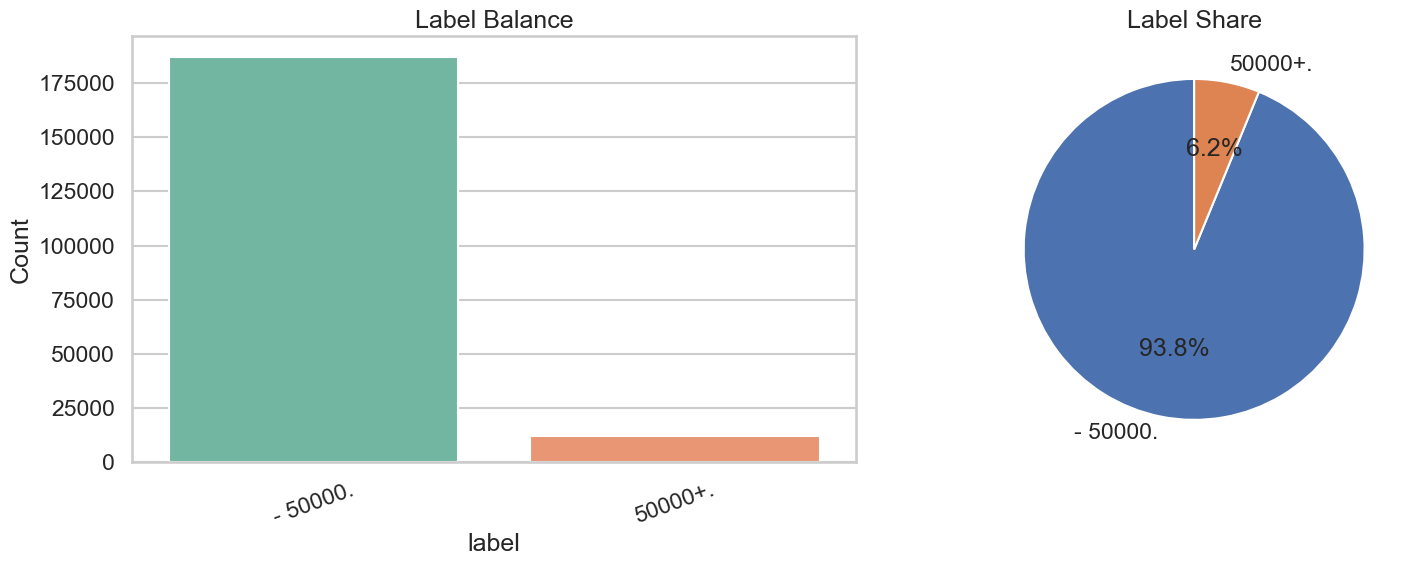

In [5]:
label_counts = df[label_col].value_counts(dropna=False)
label_pct = (label_counts / len(df) * 100).round(2)
label_summary = pd.DataFrame({"count": label_counts, "pct": label_pct})
display(label_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0], palette="Set2")
axes[0].set_title("Label Balance")
axes[0].set_xlabel(label_col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)

axes[1].pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Label Share")
plt.tight_layout()
plt.show()

## 2. Missingness

There are two kinds of absence worth separating here:

- true missing values encoded as `?`, which become `NaN`
- structural placeholders such as `Not in universe`, which are not technically missing but still tell us a feature is irrelevant for many rows

,missing_pct,missing_count
migration code-change in msa,49.967172,99696
migration code-change in reg,49.967172,99696
migration code-move within reg,49.967172,99696
migration prev res in sunbelt,49.967172,99696
country of birth father,3.364524,6713
country of birth mother,3.066814,6119
country of birth self,1.700556,3393
hispanic origin,0.438045,874
state of previous residence,0.354846,708


/var/folders/_l/02tcfqxs5z5_ryn16zmb5n380000gn/T/ipykernel_43597/1997074908.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, x="missing_pct", y="column", palette="crest")


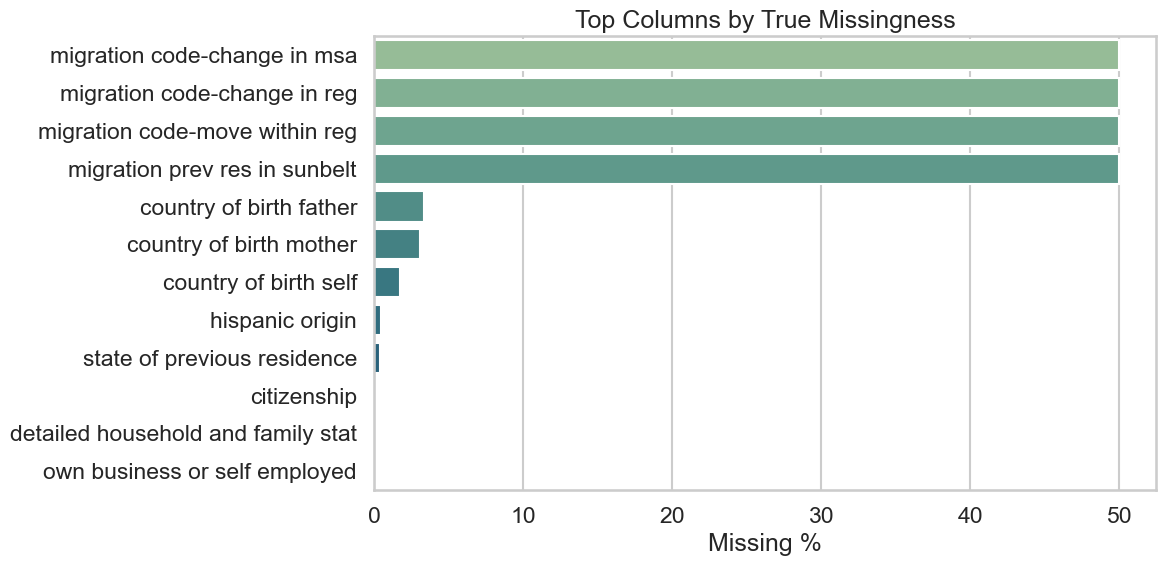

,column,not_in_universe_pct
14,fill inc questionnaire for veteran's admin,99.005628
5,reason for unemployment,96.957744
1,enroll in edu inst last wk,93.694962
6,region of previous residence,92.094646
7,state of previous residence,92.094646
4,member of a labor union,90.445212
13,family members under 18,72.288408
11,live in this house 1 year ago,50.726984
2,major industry code,50.462353
3,major occupation code,50.462353


In [6]:
missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)
missing_summary["missing_count"] = df.isna().sum()
display(missing_summary.query("missing_count > 0"))

top_missing = missing_summary.head(12).reset_index().rename(columns={"index": "column"})
plt.figure(figsize=(12, 6))
sns.barplot(data=top_missing, x="missing_pct", y="column", palette="crest")
plt.title("Top Columns by True Missingness")
plt.xlabel("Missing %")
plt.ylabel("")
plt.tight_layout()
plt.show()

not_in_universe = []
for col in categorical_cols:
    share = df[col].astype("string").str.contains("Not in universe", na=False).mean()
    if share > 0:
        not_in_universe.append((col, share * 100))

not_in_universe_df = pd.DataFrame(not_in_universe, columns=["column", "not_in_universe_pct"]).sort_values(
    "not_in_universe_pct", ascending=False
)
display(not_in_universe_df.head(12))

## 3. Quick Distribution Scan

A fast numeric scan helps us see skew, zero inflation, and potential heavy-tail behavior before modeling.

,count,mean,std,min,25%,50%,75%,max,zero_pct,missing_pct
capital gains,199523.0,434.718990,4697.531280,0.00,0.000,0.00,0.00,99999.0,96.30,0.0
dividends from stocks,199523.0,197.529533,1984.163658,0.00,0.000,0.00,0.00,99999.0,89.40,0.0
weight,199523.0,1740.380269,993.768156,37.87,1061.615,1618.31,2188.61,18656.3,0.00,0.0
wage per hour,199523.0,55.426908,274.896454,0.00,0.000,0.00,0.00,9999.0,94.33,0.0
capital losses,199523.0,37.313788,271.896428,0.00,0.000,0.00,0.00,4608.0,98.04,0.0
weeks worked in year,199523.0,23.174897,24.411488,0.00,0.000,8.00,52.00,52.0,48.11,0.0
age,199523.0,34.494199,22.310895,0.00,15.000,33.00,50.00,90.0,1.42,0.0
detailed industry recode,199523.0,15.352320,18.067129,0.00,0.000,0.00,33.00,51.0,50.46,0.0
detailed occupation recode,199523.0,11.306556,14.454204,0.00,0.000,0.00,26.00,46.0,50.46,0.0
num persons worked for employer,199523.0,1.956180,2.365126,0.00,0.000,1.00,4.00,6.0,48.11,0.0


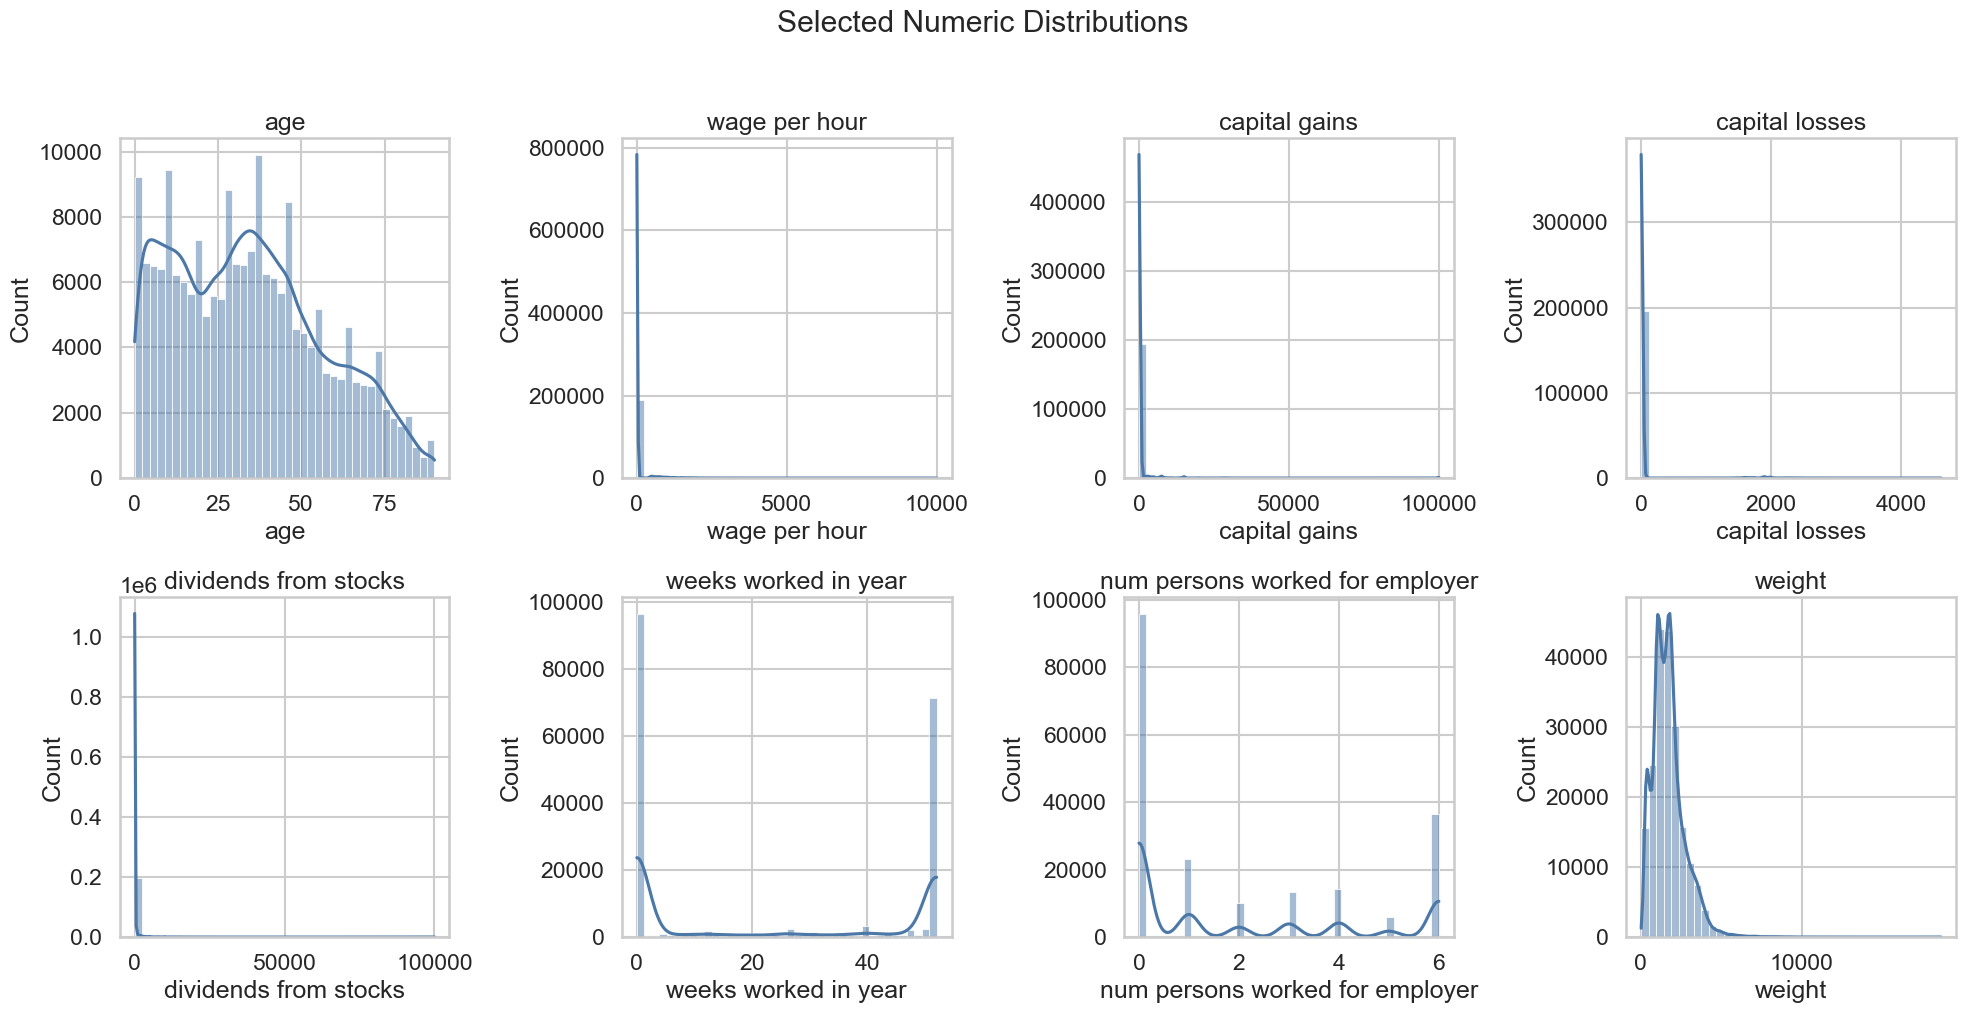

In [7]:
numeric_summary = df[numeric_cols].describe().T
numeric_summary["zero_pct"] = (df[numeric_cols].eq(0).mean() * 100).round(2)
numeric_summary["missing_pct"] = (df[numeric_cols].isna().mean() * 100).round(2)
display(numeric_summary.sort_values("std", ascending=False).head(12))

plot_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "weeks worked in year",
    "num persons worked for employer",
    "weight",
]
plot_cols = [col for col in plot_cols if col in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#4C78A8")
    ax.set_title(col)

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.suptitle("Selected Numeric Distributions", y=1.02)
plt.tight_layout()
plt.show()

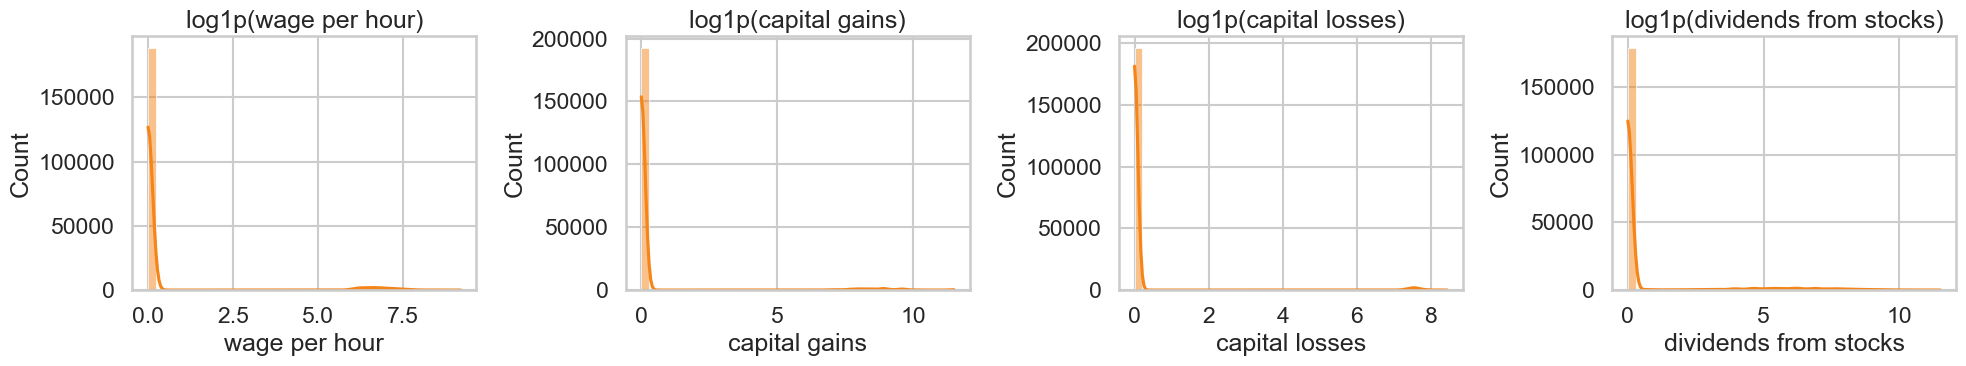

In [8]:
log_skew_cols = [col for col in ["wage per hour", "capital gains", "capital losses", "dividends from stocks"] if col in df.columns]

if log_skew_cols:
    transformed = np.log1p(df[log_skew_cols])
    fig, axes = plt.subplots(1, len(log_skew_cols), figsize=(5 * len(log_skew_cols), 4))
    if len(log_skew_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, log_skew_cols):
        sns.histplot(transformed[col], bins=40, kde=True, ax=ax, color="#F58518")
        ax.set_title(f"log1p({col})")
    plt.tight_layout()
    plt.show()

## 4. Category Structure and Outcome Separation

For tabular social data, marginal distributions are useful, but the more interesting question is which categories separate the label.

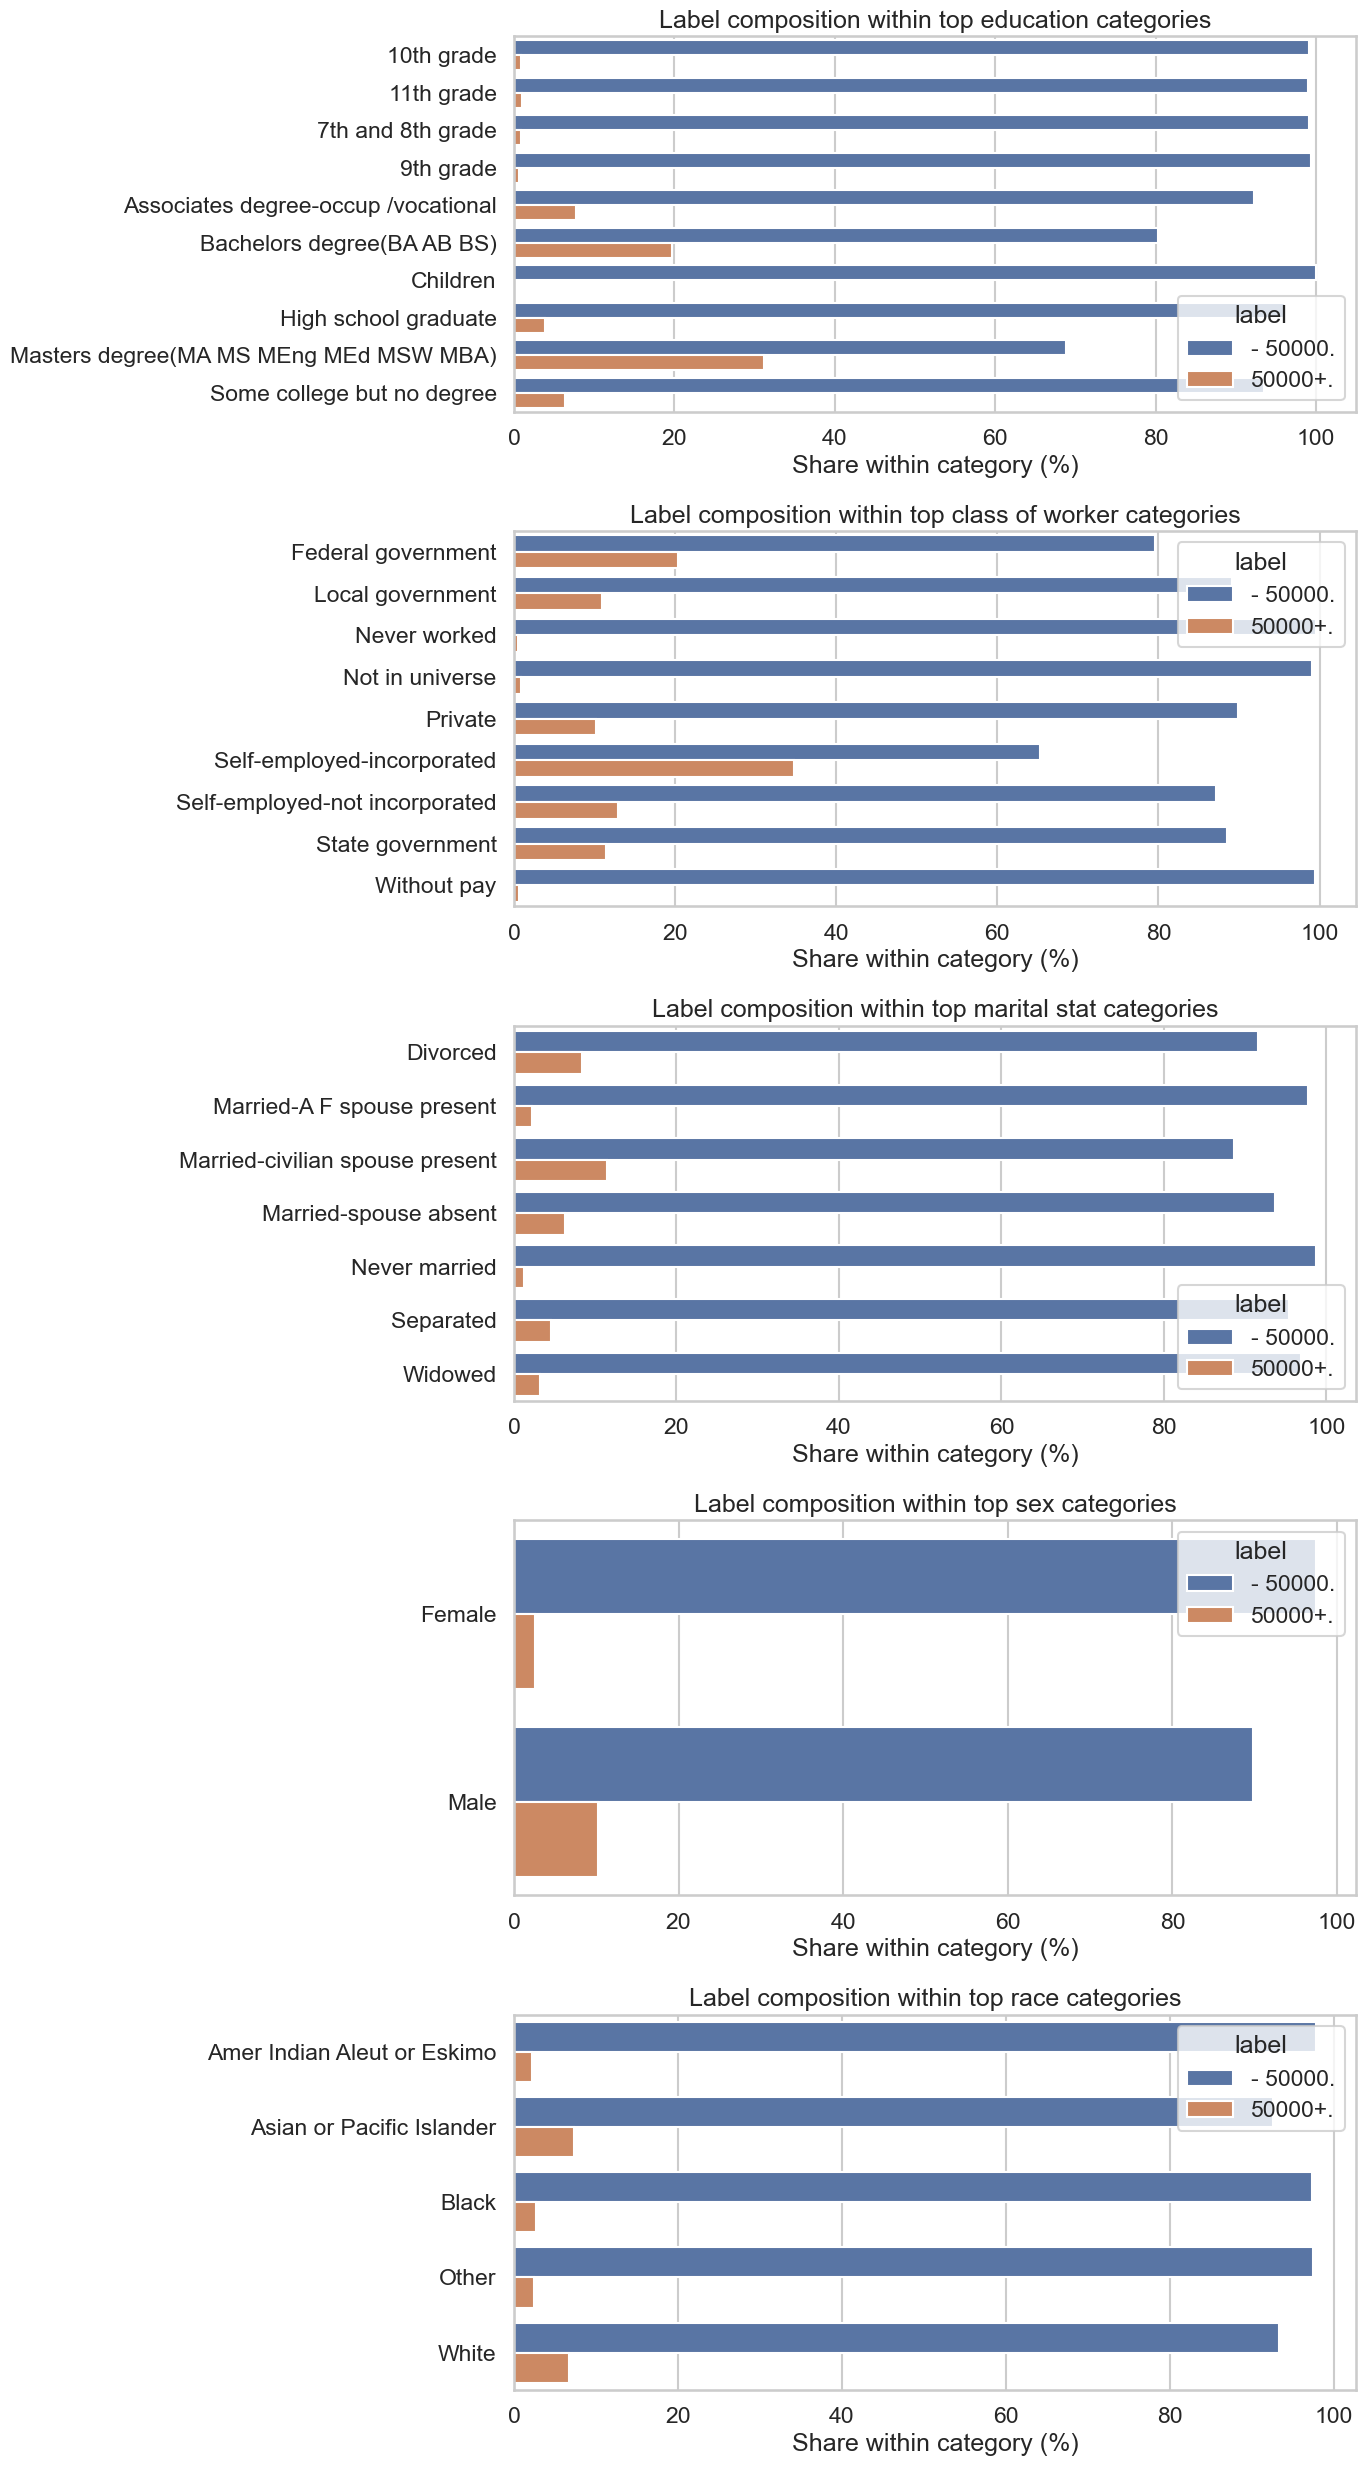

In [9]:
important_cats = [
    "education",
    "class of worker",
    "marital stat",
    "sex",
    "race",
]
important_cats = [col for col in important_cats if col in df.columns]

fig, axes = plt.subplots(len(important_cats), 1, figsize=(14, 5 * len(important_cats)))
if len(important_cats) == 1:
    axes = [axes]

for ax, col in zip(axes, important_cats):
    top_levels = df[col].value_counts().head(10).index
    plot_df = df[df[col].isin(top_levels)].copy()
    rate_df = (
        plot_df.groupby(col)[label_col]
        .value_counts(normalize=True)
        .rename("share")
        .mul(100)
        .reset_index()
    )
    sns.barplot(data=rate_df, x="share", y=col, hue=label_col, ax=ax)
    ax.set_title(f"Label composition within top {col} categories")
    ax.set_xlabel("Share within category (%)")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [10]:
positive_label = df[label_col].value_counts().index[-1] if "50000+." not in df[label_col].dropna().unique() else "50000+."
target_rate = df.assign(target=(df[label_col] == positive_label).astype(int))

rate_tables = {}
for col in important_cats:
    rate_tables[col] = (
        target_rate.groupby(col)
        .agg(sample_size=("target", "size"), positive_rate=("target", "mean"))
        .sort_values(["positive_rate", "sample_size"], ascending=[False, False])
        .head(12)
    )
    rate_tables[col]["positive_rate"] = (rate_tables[col]["positive_rate"] * 100).round(2)

for col, table in rate_tables.items():
    print(f"\nTop categories by positive-label rate: {col}")
    display(table)


Top categories by positive-label rate: education


,sample_size,positive_rate
education,,
Prof school degree (MD DDS DVM LLB JD),1793,54.04
Doctorate degree(PhD EdD),1263,52.02
Masters degree(MA MS MEng MEd MSW MBA),6541,31.16
Bachelors degree(BA AB BS),19865,19.71
Associates degree-academic program,4363,9.44
Associates degree-occup /vocational,5358,7.71
Some college but no degree,27820,6.42
High school graduate,48407,3.88
12th grade no diploma,2126,1.60



Top categories by positive-label rate: class of worker


,sample_size,positive_rate
class of worker,,
Self-employed-incorporated,3265,34.73
Federal government,2925,20.41
Self-employed-not incorporated,8445,12.91
State government,4227,11.47
Local government,7784,10.88
Private,72028,10.17
Not in universe,100245,0.90
Without pay,165,0.61
Never worked,439,0.46



Top categories by positive-label rate: marital stat


,sample_size,positive_rate
marital stat,,
Married-civilian spouse present,84222,11.40
Divorced,12710,8.39
Married-spouse absent,1518,6.32
Separated,3460,4.57
Widowed,10463,3.15
Married-A F spouse present,665,2.26
Never married,86485,1.29



Top categories by positive-label rate: sex


,sample_size,positive_rate
sex,,
Male,95539,10.17
Female,103984,2.56



Top categories by positive-label rate: race


,sample_size,positive_rate
race,,
Asian or Pacific Islander,5835,7.37
White,167365,6.73
Black,20415,2.65
Other,3657,2.49
Amer Indian Aleut or Eskimo,2251,2.18


## 5. Additional Checks That Matter

A few extra diagnostics are often useful before training:

- duplicate rows can inflate confidence
- numeric correlation highlights redundancy
- year drift can indicate a mild temporal shift in the label

duplicate rows: 3229 (1.62%)


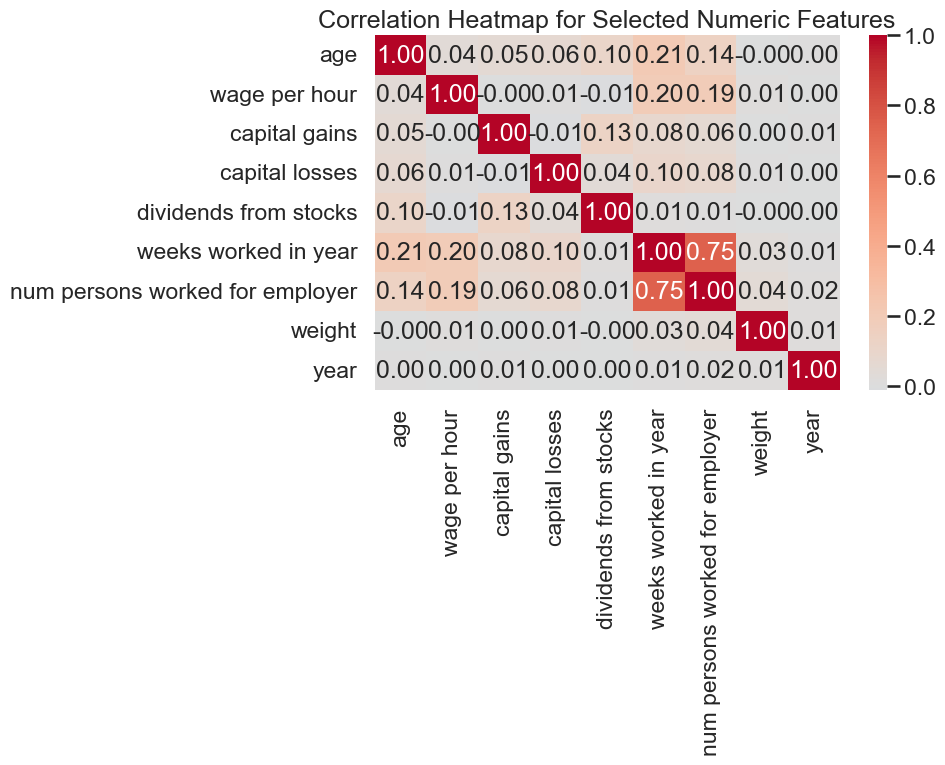

,year,sample_size,positive_rate
0,94,99827,5.849119
1,95,99696,6.562951


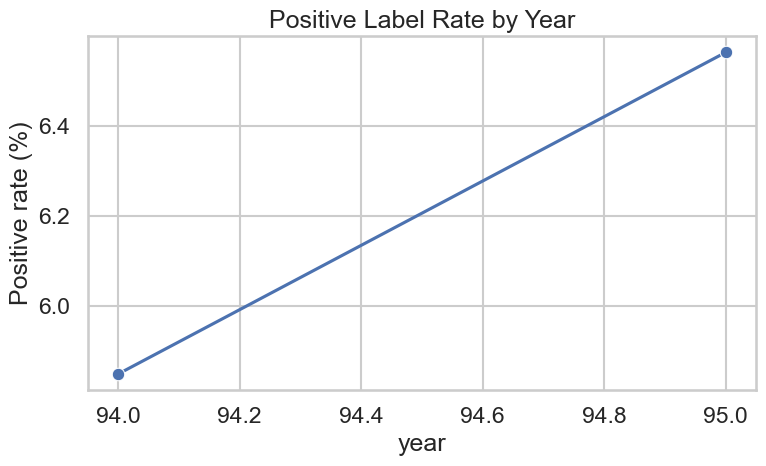

In [11]:
duplicate_rows = df.duplicated().sum()
print(f"duplicate rows: {duplicate_rows} ({duplicate_rows / len(df) * 100:.2f}%)")

corr_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "weeks worked in year",
    "num persons worked for employer",
    "weight",
    "year",
]
corr_cols = [col for col in corr_cols if col in df.columns]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Selected Numeric Features")
plt.tight_layout()
plt.show()

if "year" in df.columns:
    year_rate = (
        target_rate.groupby("year")
        .agg(sample_size=("target", "size"), positive_rate=("target", "mean"))
        .reset_index()
    )
    year_rate["positive_rate"] = year_rate["positive_rate"] * 100
    display(year_rate)
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=year_rate, x="year", y="positive_rate", marker="o")
    plt.title("Positive Label Rate by Year")
    plt.ylabel("Positive rate (%)")
    plt.tight_layout()
    plt.show()

## Takeaways Template

After running the notebook, use this section to summarize what stands out:

- how severe the class imbalance is
- whether true missingness is small or concentrated
- which numeric variables are heavily zero-inflated or skewed
- which categorical groups appear most associated with the positive label
- whether the `year` field suggests any distribution shift